# Taking a closer look at what is in each cluster

**Author:** Erik Am&eacute;zquita

**Date:** February 2026

This is a short notebook on how to generate Mapper graphs with a variety of parameters. Mapper is one of the many tools available from Topological Data Analysis (TDA). In this case, the analysis is targeted to RNAseq data. Choosing the right parameters is a combination of math, art, and some luck. This is by no means an exhaustive list of things to try, but it (hopefully) will provide a good starting point from which finer analyses can be devised.

## On the usage of this Notebook

You don't need to know how to code to use this notebook. If you've managed to get a open this very notebook with Jupyter, you've already done the hardest part. You will only need to change three numbers and one/two names in Part IV. Look for the sparkle symbols (&#10024;) below that will encourage where to change values.

- You only need to click run for *all* cells.
- You only need to run Parts I thru III *once* (running them again won't do anything bad but will take longer).
- You will need to edit the code for Part IV, and Part IV only: it will be easy, I promise.
- After you edit Part IV, you'll need to run Part V and act on Part VI
- You will repeat Parts IV thru VI to explore the data through Mapper

## Some observations on what to expect

There might be exceptions, but in general you might expect

- Changing `lens` (filter function) will affect the **most** the final color distribution (and possibly shape) of the mapper graph
- As well as choosing between using one or two lens functions at time
- The higher the number of `bins`, the more nodes you'll have in the mapper
- The higher the `overlap` percentage, the more edges you'll have between nodes
- Low `eps` value for clustering can result in a low percentage of unique genes represented in the mapper graph

---

# Part I: Imports

We start importing some standard libraries and sublibraries for non-TDA stuff. For the mapper-specific computations, we'll use `kmapper.`

In [1]:
import os
import glob
import copy
import re
import itertools
from importlib import reload

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import networkx as nx
import utils

import matplotlib as mpl

In [93]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
from goatools.utils import read_geneset
from goatools.obo_parser import GODag
from goatools.obo_parser import OBOReader
from goatools.anno.idtogos_reader import IdToGosReader
from goatools.go_enrichment import GOEnrichmentStudy
from goatools.base import download_go_basic_obo

---

# Part II: Load and transform the reads

- Repeat the transformation as in the Notebook 01

In [2]:
fs = 12
min_tpm = 100
nlabels = ['min', 'mean', 'max', 'median', 'std', 'size', 'sqrtsize', 'cbrtsize']
plot_kw = dict(format='png', bbox_inches='tight', dpi=150)

src = os.pardir + os.sep + 'raw' + os.sep
dst = os.pardir + os.sep + 'outputs' + os.sep
pdst = os.pardir + os.sep + 'plots' + os.sep
if not os.path.isdir(pdst):
    os.mkdir(pdst)
p = re.compile('(.*)_B(.*)_Ov(.*)_dbscan(.*)')

# List the name of the lines, their repetitions
# and pairs to compare
reps = [1,2]
lines = ['BA24','BM24','IA24','IM24','ZA24','ZM24']
full_lines = list(itertools.chain(*[[ '{}_{}'.format(l,r) for r in reps ] for l in lines]))
comparisons = [(0,1),(2,3),(4,5),(0,2),(0,4),(1,3),(1,5)]

# Read the count number file
filename = src + 'readCounts_Xa7_msu_v7.csv'
data = pd.read_csv(filename).set_index('Geneid')
genelength = data['Length']
data = data[full_lines] + 1
rpk = data.div(genelength, axis='index')
print('Original dataframe dimensions:\t', rpk.shape)

# Standardize expression levels
# Remove genes where max expression level is under 100
tpm = utils.count_normalization(data, rpk, lines, reps, normalize_flag='DESeq2')
tpm = tpm.loc[tpm.max(axis = 1) > min_tpm]
print('After initial cleanup:\t', tpm.shape)

# Get all the foldchange values
# One per pair comparison
fcs = pd.DataFrame(np.nan, index=tpm.index, columns = ['{} vs {}'.format(lines[comp[0]],lines[comp[1]]) for comp in comparisons])
for comp in comparisons:
    key = '{} vs {}'.format(lines[comp[0]],lines[comp[1]])
    fcs[key] = utils.foldchange(comp, rpk, tpm, lines, reps, alpha=1e-3)

fc = fcs.sum(axis=1)
lfc = np.log10(fc)
lens = lfc.values.copy()

TPM = tpm.round(0).astype(int)
TPM.head()

Original dataframe dimensions:	 (55986, 12)
After initial cleanup:	 (19601, 12)


,BA24_1,BA24_2,BM24_1,BM24_2,IA24_1,IA24_2,IM24_1,IM24_2,ZA24_1,ZA24_2,ZM24_1,ZM24_2
Geneid,,,,,,,,,,,,
LOC_Os01g01010,1975,1765,3171,1482,2307,1687,2259,2386,2075,1489,2546,2490
LOC_Os01g01030,101,77,121,94,178,146,95,197,115,167,180,237
LOC_Os01g01040,1495,926,1816,1283,1641,1551,1428,1629,1501,1325,1419,1610
LOC_Os01g01050,1128,1000,1920,1268,1365,1216,1358,1503,1314,898,1530,1678
LOC_Os01g01060,4816,3366,3558,2809,4168,5790,3395,2704,5439,5360,2966,3215


---

# Part III: Load the mapper graph

You've already computed and saved the mapper graphs as HTML files in the Notebook 01. Now we simply load those HTMLs for further analysis.

### &#10024; Change the filename accordingly. Make sure it ends in `.html`

In [3]:
# Replace the filename 
filename = dst + 'log_isolation+sd_B110_Ov50_dbscan0,4.html'
poskey = 'kamada kawai'

# You don't need to change anything else
# Figure out Mapper parameters based on the filename
bname = os.path.splitext(os.path.split(filename)[1])[0]
filters, binno, overlap, dbscan = p.findall(bname)[0]
filters = filters.replace('_',' ').replace('+',' & ').title().replace('Sd','SD')
dbscan = dbscan.replace(',','.')
overlap += '%'
print(filters, binno, overlap, dbscan, sep='\t')
mtitle = f'Filters: {filters}, Bins#: {binno}, Overlap: {overlap}, DBSCAN($\\varepsilon$): {dbscan}'
fname = pdst + bname

dfpos = pd.read_csv(os.pardir + os.sep + 'positions' + os.sep + bname + '.csv', index_col=0)
pos = dict(zip(dfpos.index, dfpos[[poskey+'_x', poskey+'_y']].to_numpy()))
ffname = fname+'_'+poskey.replace(' ', '_')

Log Isolation & SD	110	50%	0.4


Now we load the HTML mapper data and make a Networkx graph out of it.
- If Kamada Kawai Layout takes toooo much time, comment it out by adding a `#` in front of all the references

In [4]:
# Load the actual Mapper info
with open(filename, encoding="utf-8") as f:
    jdict = utils.html2json(f.read())
graph = utils.json2mapperG(jdict)

alpha = 0.001
metanodes = dict()
for comp in comparisons:
    dkey = '{} vs {}'.format(lines[comp[0]],lines[comp[1]])
    LFC = np.log10(fcs[dkey].copy())
    meta = pd.DataFrame(np.nan, index=graph['nodes'].keys(), columns=nlabels[:5])
    for key in meta.index:
        nn = LFC.iloc[ graph['nodes'][key] ]
        for attr in meta.columns:
            meta.loc[key, attr] = getattr( np, attr)(nn)
        
    mini, maxi = np.quantile( LFC , [alpha, 1-alpha])
    LFC[LFC < mini] = mini
    LFC[LFC > maxi] = maxi
    
    metanodes[dkey] = meta

metavmax = dict()
for comp in comparisons:
    dkey = '{} vs {}'.format(lines[comp[0]],lines[comp[1]])
    metavmax[dkey] = metanodes[dkey]['mean'].sort_values().iloc[-2]

# Compute some basic metrics for each node
metanode = pd.DataFrame(np.nan, index=graph['nodes'].keys(), columns=nlabels)
for key in metanode.index:
    nn = lens[ graph['nodes'][key] ]
    for attr in nlabels[:5]:
        metanode.loc[key, attr] = getattr( np, attr)(nn)
    metanode.loc[key, 'size'] = len(nn)
metanode['sqrtsize'] = np.sqrt(metanode['size'])
metanode['cbrtsize'] = np.cbrt(metanode['size'])

# Make a networkx G with the mapper data
G = utils.mapper2networkx(graph)
nG = list(G.nodes)
n2g = dict(zip(nG, range(1,1+len(nG))))
edge_weights = [None] + list(list(G.edges(data=True))[0][-1].keys())[1:]

# Get the largest connected component
# Some layouts only work with a connected component
S = [G.subgraph(c).copy() for c in sorted(nx.connected_components(G), key=len, reverse=True)]
nS = list(S[0].nodes)

# Get the darkest node
lowest = metanode.loc[ nS , 'median'].idxmin()

# Copy G and connect all the components with new edges of weight `zeroweight`
# We'll then remove these temporary edges
zeroweight = 3
temp_edge = []
Gcpy = G.copy()

# "Remove" the temporary edges by setting their weight to zero
nx.set_edge_attributes(Gcpy, dict(zip(temp_edge, np.zeros(len(temp_edge)))), 'size')
width = np.array([ foo[2] for foo in  Gcpy.edges(data='size')])
drawkw = dict(G=Gcpy, node_size=0, width = 0.75*np.cbrt(width), 
              edge_color=width, edge_cmap=mpl.colormaps['Greys'], edge_vmin=-7, edge_vmax=7,
              with_labels=False, hide_ticks=True, font_size=6)

stdvmax = metanode.loc[nG, 'std'].sort_values().iloc[-3]
lvmax = metanode.loc[nS, 'mean'].sort_values().iloc[-2]

drawSkw = copy.deepcopy(drawkw)
widthS = np.array([ foo[2] for foo in  S[0].edges(data='size')])
drawSkw['G'] = S[0]
drawSkw['width'] = 0.75*np.cbrt(widthS)
drawSkw['edge_color'] = widthS

Plot the mapper graph based on different layouts
- If you removed the Kamada Kawai layout, replace `kamada kawai` with `random` below.
- Else leave it unchanged

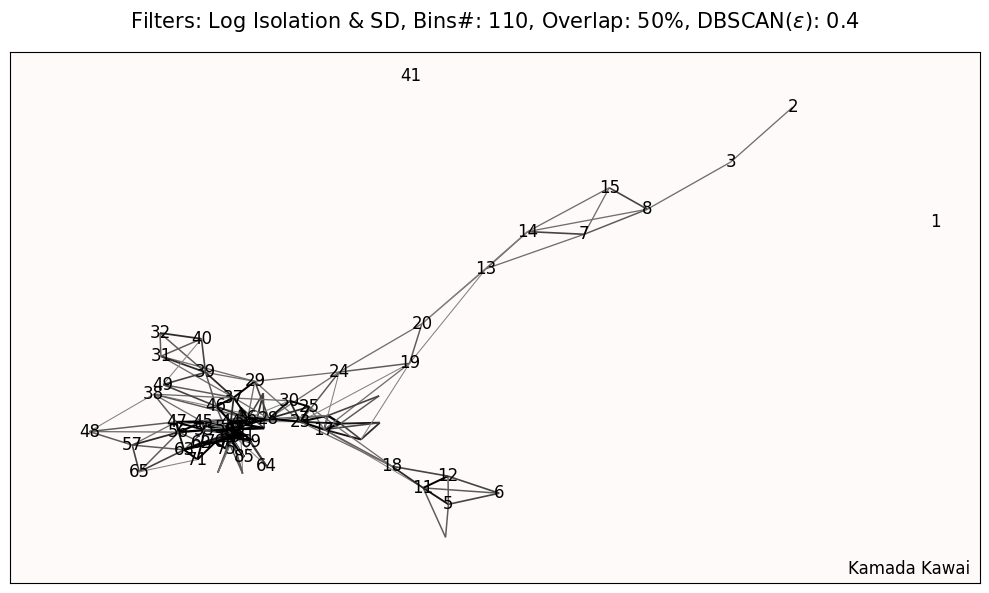

In [5]:
scatterkw = dict(s=20*metanode.loc[nG, 'cbrtsize'], cmap='viridis', ec='k', zorder=4)

fig, ax = plt.subplots(1,1, figsize=(10,6)); i = 0
ax = np.atleast_1d(ax).ravel()
nx.draw_networkx(pos=pos, ax=ax[i], **drawkw )
#ax[i].scatter(dfpos[poskey+'_x'], dfpos[poskey+'_y'] , c=metanode.loc[nG, 'median'], vmin=0, vmax=lvmax, label='LFC', **scatterkw)
ax[i].text(0.99, 0.01, poskey.title(), transform=ax[i].transAxes, fontsize=fs, ha='right', va='bottom')
for index in metanode.loc[nG, 'median'][ metanode.loc[nG, 'median'] >= 0.95 ].index:
    ax[i].text(*pos[index], n2g[index], fontsize=fs, ha='center', va='center', zorder=5)
ax[i].set_facecolor('snow')
fig.suptitle(mtitle, fontsize=1.25*fs)
fig.tight_layout();

### &#10024; Make note of the layout that looks better to you. Make sure it is all lowercase.

---

# Part IV: Computing "strandiness"

**Things to look for:**

- Mock vs Attack (`_A vs _M`) should be sort of similar across the three rice lines (`B, I, Z`). Make note of any outstanding differences
- Same for Attack vs Attack
- Same for Mock vs Mock

In [49]:
np.log10(1.25)

0.09691001300805642

In [59]:
means = np.hstack([ metanodes[key]['median'] for key in metanodes ])
print(means.min(), means.max())

-1.3858847956659017 0.810014983721565


In [66]:
np.quantile(means, 0.95)

0.3758698564749551

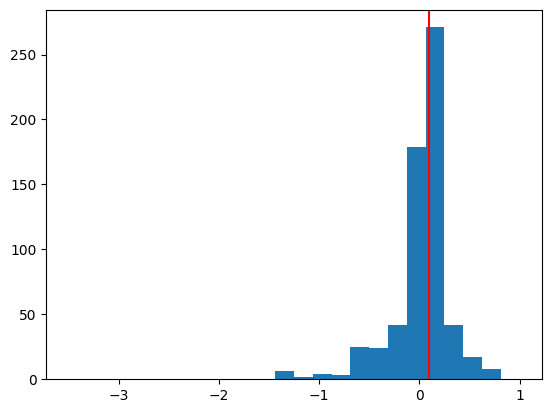

In [60]:
thr = np.log10(1.25)
bins = np.linspace(-3.5,1,25)
plt.hist(np.hstack([ metanodes[key]['median'] for key in metanodes ]), bins=bins)
plt.axvline(thr, c='r');

In [68]:
thr = np.quantile(means, 0.90)
foo

Index(['cube152_cluster0', 'cube188_cluster0', 'cube199_cluster0',
       'cube214_cluster0'],
      dtype='object')

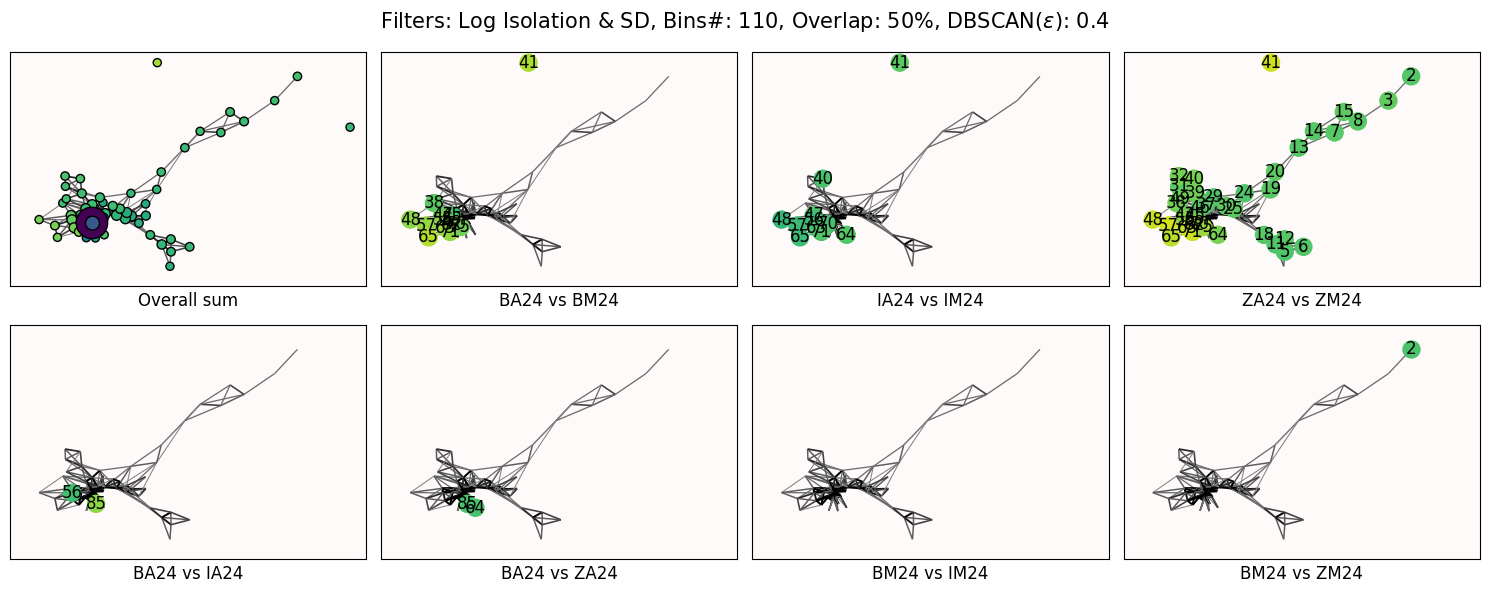

In [71]:
fig, ax = plt.subplots(2, 4, figsize=(15,6), sharex=True, sharey=True)
ax = ax.ravel(); i = 0

for a in ax:
    a.set_facecolor('snow')
    nx.draw_networkx(pos=pos, ax=a, **drawkw )
ax[i].scatter(dfpos[poskey+'_x'], dfpos[poskey+'_y'] , c=metanode.loc[nG, 'median'], vmin=0, vmax=lvmax, **scatterkw)
ax[i].set_xlabel('Overall sum', fontsize=fs)
for comp in comparisons:
    i += 1
    key = '{} vs {}'.format(lines[comp[0]],lines[comp[1]])
    foo = metanodes[key].loc[nG]
    foo = foo[ foo['mean']  > thr ].index
    bar = dfpos.loc[foo, [poskey + '_x', poskey + '_y']].T.to_numpy()
    ax[i].scatter(*bar, c=metanodes[key].loc[foo, 'median'], vmin=-1.5, vmax=max(metavmax.values()), zorder=4, s=150)
    for index in foo:
        ax[i].text(*pos[index], n2g[index], fontsize=fs, ha='center', va='center', zorder=5)
    ax[i].set_xlabel(key, fontsize=fs)

fig.suptitle(mtitle, fontsize=1.25*fs)
fig.tight_layout();

In [136]:
comp = comparisons[2]
key = '{} vs {}'.format(lines[comp[0]],lines[comp[1]])
print(key)
topvals = metanodes[key].loc[nG]
topvals = topvals[ topvals['mean']  > thr ]
print([ n2g[n] for n in topvals.index ] )
topvals.head()

ZA24 vs ZM24
[2, 3, 5, 6, 7, 8, 11, 12, 13, 14, 15, 18, 19, 20, 24, 25, 29, 30, 31, 32, 37, 38, 39, 40, 41, 45, 46, 47, 48, 49, 55, 56, 57, 62, 63, 64, 65, 70, 71, 75]


,min,mean,max,median,std
cube188_cluster0,0.060488,0.271193,0.376828,0.312717,0.108920
cube199_cluster0,0.283905,0.368690,0.446490,0.376828,0.052536
cube211_cluster0,0.173909,0.273844,0.350754,0.297651,0.059001
cube212_cluster0,0.233736,0.311445,0.357855,0.311473,0.038283
cube213_cluster0,0.218065,0.336894,0.421918,0.337775,0.062673


In [142]:
gnodes = [ n2g[n] for n in topvals.index]
H = G.subgraph(topvals.index)
S = [H.subgraph(c).copy() for c in sorted(nx.connected_components(H), key=len, reverse=True)]
gene_groups = [set() for _ in range(len(S)) ]

print('Number of subgraphs:\t', len(S))

for i in range(len(S)):
    for node in S[i]:
        foo = TPM.iloc[graph['nodes'][node]].index.values
        gene_groups[i] |= set(foo)
    print('Subgraph:', i, 'has', len(S[i]), 'nodes and', len(gene_groups[i]),'different genes.')
    print('\t', [ n2g[n] for n in S[i] ])

Number of subgraphs:	 4
Subgraph: 0 has 20 nodes and 92 different genes.
	 [5, 6, 38, 62, 47, 65, 71, 63, 70, 56, 48, 25, 18, 11, 57, 45, 30, 12, 55, 75]
Subgraph: 1 has 18 nodes and 60 different genes.
	 [46, 20, 40, 19, 7, 8, 29, 37, 49, 13, 2, 24, 32, 3, 31, 14, 15, 39]
Subgraph: 2 has 1 nodes and 5 different genes.
	 [41]
Subgraph: 3 has 1 nodes and 5 different genes.
	 [64]


In [94]:
filename = os.pardir + os.sep + 'raw' + os.sep + 'rice_GO_terms.csv'
if not os.path.isfile(filename):
    gocols = ['Locus', 'GO ID', 'Type', 'GO term', 'TAIRLocus']
    goslimfile = os.pardir + os.sep + 'raw' + os.sep + 'osa1_r7.all_models.GOSlim.txt'
    goslim = pd.read_csv(goslimfile, sep='\t', header=None).drop(columns=4)
    goslim.columns = gocols
    goslim['Locus'] = goslim['Locus'].str.replace('mRNA','gene')
    foo = ['' for _ in range(len(goslim)) ]
    for i in range(len(foo)):
        if 'LOC' in goslim.iloc[i,0]:
            foo[i] = goslim.iloc[i,0].split('.')[0]
        else:
            foo[i] = goslim.iloc[i,0]
    goslim['Locus'] = foo
    print(goslim.shape)
    goslim['TAIRLocus'] = goslim['TAIRLocus'].str.replace('TAIR:','')
    goterms = goslim.drop_duplicates(ignore_index=True)
    goterms.to_csv(filename, index=False)

dfterms = pd.read_csv(filename)
print(dfterms.shape)
dfterms

(132323, 5)


,Locus,GO ID,Type,GO term,TAIRLocus
0,LOC_Os01g01010,GO:0030234,F,enzyme regulator activity,AT3G59570
1,LOC_Os01g01010,GO:0007165,P,signal transduction,AT3G59570
2,LOC_Os01g01010,GO:0006139,P,"nucleobase, nucleoside, nucleotide and nucleic...",AT3G59570
3,LOC_Os01g01010,GO:0009056,P,catabolic process,AT3G59570
4,LOC_Os01g01010,GO:0005622,C,intracellular,AT3G59570
...,...,...,...,...,...
132318,ChrUn.fgenesh.gene.96,GO:0008152,P,metabolic process,AT1G76680
132319,ChrUn.fgenesh.gene.96,GO:0008150,P,biological_process,AT1G76680
132320,ChrUn.fgenesh.gene.96,GO:0009987,P,cellular process,AT1G76680
132321,ChrUn.fgenesh.gene.96,GO:0006629,P,lipid metabolic process,AT1G76680


In [96]:
import json

# Load the go-basic.obo file if it exists, else download it.
fin_obo   = src + "go-basic.obo"
if not os.path.isfile(fin_obo):
    fin_obo = download_go_basic_obo()

with open(fin_obo, encoding="utf-8") as f:
    obo = f.read().replace('"','')

terms = obo.split('\n\n[Term]\n')[1:]
terms[-1] = terms[-1].split('\n\n[Typedef]\n')[0]

goterms = dict()
for term in terms:
    jstr = '{' + ','.join(['"' + t.strip().replace('\\','').replace(': ','":"',1) + '"' for t in term.split('\n') ]) + '}'
    d = json.loads(jstr)
    goterms[ d['id'] ] = d

goreplace = dict()
for key in goterms:
    goreplace[key] = []
    if 'replaced_by' in goterms[key]:
        goreplace[key].append(goterms[key]['replaced_by'])
    if 'consider' in goterms[key]:
        goreplace[key].append(goterms[key]['consider'])
    if len(goreplace[key]) == 0:
        del goreplace[key]

goremove = []
for key in goterms:
    if ('is_obsolete' in goterms[key]) and (key not in goreplace):
        if goterms[key]['is_obsolete'] == 'true':
            goremove.append(key)

GO:0008619
5488


In [97]:
foo = ','.join(dfterms['GO ID'].values)
for term in goreplace:
    foo = foo.replace(term , goreplace[term][0])
for term in goremove:
    foo = foo.replace(term, 'blank')
dfterms['GO ID'] = foo.split(',')
dfterms = dfterms[dfterms['GO ID'] != 'blank']

In [101]:
population_ids = set(tpm.index)


../raw/go-basic.obo: fmt(1.2) rel(2026-01-23) 42,036 Terms


In [102]:
# List all unique TAIR loci associated with orthogroups and write to a file
tair_file = src + "all_os.txt"
with open(tair_file, "w") as fp:
    fp.write("\n".join(dfterms["Locus"].unique()))

# Create TAIR Locus - GO ID associations and write to file
assoc_file = src + "go_association.txt"
tair_grouped = dfterms.groupby("Locus")["GO ID"].aggregate(set)
with open(assoc_file, "w") as fp:
    for t in tair_grouped.index:
        fp.write(t + "\t" + ";".join(list(tair_grouped[t])) + "\n")

In [103]:
# Populate necessary variables to run GO Enrichment

annoobj = IdToGosReader(assoc_file, godag=godag)
id2gos = annoobj.get_id2gos()

# GO Enrichment
goeaobj = GOEnrichmentStudy(
    population_ids,
    annoobj.get_id2gos(),
    godag,
    methods=['bonferroni', 'fdr_bh'],
    pvalcalc='fisher_scipy_stats')

HMS:0:00:00.398218 127,495 annotations READ: ../raw/go_association.txt 
25463 IDs in loaded association branch, biological_process
25463 IDs in loaded association branch, biological_process

Load  Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 85% 16,690 of 19,601 population items found in association


In [125]:
results = goeaobj.run_study_nts(gene_groups[0])


Runing  Ontology Analysis: current study set of 17 IDs.
 94%     16 of     17 study items found in association
100%     17 of     17 study items found in population(19601)
Calculating 149 uncorrected p-values using fisher_scipy_stats
     149 terms are associated with 16,690 of 19,601 population items
      54 terms are associated with     16 of     17 study items
  METHOD bonferroni:
       0 GO terms found significant (< 0.05=alpha) (  0 enriched +   0 purified): local bonferroni
       0 study items associated with significant GO IDs (enriched)
       0 study items associated with significant GO IDs (purified)
  METHOD fdr_bh:
       0 GO terms found significant (< 0.05=alpha) (  0 enriched +   0 purified): statsmodels fdr_bh
       0 study items associated with significant GO IDs (enriched)
       0 study items associated with significant GO IDs (purified)


In [122]:
# Collect GO Enrichment results, format and write to csv file.
goea_out = src + "gotest.csv"

# Column headers
hdrs = ["Namespace", "GO ID", "Enriched/Purified", "GO Terms", "pval_uncorr", "Benjamimi/Hochberg", "Bonferroni", "Study Ratio", "Population Ratio"]

# Row values pattern
pat = "{NS}\t{GO}\t{e}\t{GOTERM}\t{PVAL:8.2e}\t\
       {BH:8.2e}\t{BONF:8.2e}\t{RS:>12}\t{RP:>12}\n"

# Write to file, one row at a time: iff adjusted p-value < 0.05
with open(goea_out, "w") as fp:
    fp.write("\t".join(hdrs) + "\n")
    for ntd in sorted(results, key=lambda nt: [nt.p_uncorrected, nt.GO]):
        if ntd.p_fdr_bh <= 0.05:
            ogs = dfterms[dfterms["GO ID"] == ntd.GO]["Locus"].tolist()
            fp.write(pat.format(
                    NS=ntd.NS,
                    GO=ntd.GO,
                    e=ntd.enrichment,
                    GOTERM=ntd.goterm.name,
                    RS='{}/{}'.format(*ntd.ratio_in_study),
                    RP='{}/{}'.format(*ntd.ratio_in_pop),
                    PVAL=ntd.p_uncorrected,
                    BONF=ntd.p_bonferroni,
                    BH=ntd.p_fdr_bh))

print(f"Wrote results to {goea_out}")

Wrote results to ../raw/gotest.csv


---

# SCRATCH SPACE: IGNORE EVERYTHING BELOW THIS LINE

# What genes are in what cluster

In [30]:
group = set()
for i in range(5):
    node = top5[i]
    foo = TPM.iloc[graph['nodes'][node]].index.values
    group |= set(foo)
group = list(group)
print(group)

['LOC_Os05g25770', 'LOC_Os02g36110', 'LOC_Os05g05940', 'LOC_Os01g50100', 'LOC_Os10g39260', 'LOC_Os05g05680', 'LOC_Os03g15780', 'LOC_Os03g12500', 'LOC_Os01g70490', 'LOC_Os02g39930', 'LOC_Os07g09340', 'LOC_Os02g57720', 'LOC_Os11g31190', 'LOC_Os03g55070', 'LOC_Os03g03450', 'LOC_Os01g21250', 'LOC_Os11g42200', 'LOC_Os03g14990', 'LOC_Os01g52530', 'LOC_Os02g48690', 'LOC_Os05g25640', 'LOC_Os07g39270', 'LOC_Os01g58240', 'LOC_Os07g04990', 'LOC_Os07g03710', 'LOC_Os03g61960', 'LOC_Os02g36210', 'LOC_Os12g16720']


In [22]:
subset.loc[group].sort_values(by='fc', ascending=False)

,BA24_1,BA24_2,BM24_1,BM24_2,IA24_1,IA24_2,IM24_1,IM24_2,ZA24_1,ZA24_2,ZM24_1,ZM24_2,fc
Geneid,,,,,,,,,,,,,
LOC_Os11g31190,23940,15054,17,18,15250,19486,193,101,25460,29015,123,113,608.523318
LOC_Os02g36210,25649,21069,461,279,9420,16892,237,169,23935,33479,489,335,23.076692
LOC_Os02g36110,25464,23230,1036,1005,10011,13835,947,668,22469,31473,685,1047,17.577898
LOC_Os11g42200,10992,6063,361,182,6774,22644,131,189,10557,19577,457,281,5.476717
LOC_Os01g52530,20488,15824,3091,2036,10788,12472,1397,1812,16850,25959,1307,1880,5.320818
LOC_Os07g39270,25388,22022,3668,4339,11189,16480,3328,3322,24001,31338,2936,3278,4.961505
LOC_Os07g03710,16390,18478,3597,5159,5390,16804,5548,1489,22706,17879,1688,1453,3.982052
LOC_Os04g05650,23380,22201,6862,4990,12828,17954,5926,3753,19553,20993,3954,5162,3.845905
LOC_Os10g39300,23980,18271,3691,7384,5114,25645,12474,6508,20335,18180,1105,2564,3.814874


In [15]:
key = 'cube280_cluster0'
fcs.iloc[graph['nodes'][key] ]

,BA24 vs BM24,IA24 vs IM24,ZA24 vs ZM24,BA24 vs IA24,BA24 vs ZA24,BM24 vs IM24,BM24 vs ZM24
Geneid,,,,,,,
LOC_Os02g40890,2.489885,2.013959,2.011111,1.101247,1.189592,1.122649,1.040747
LOC_Os07g32880,1.382020,1.662068,2.198388,1.304640,1.006915,1.569009,1.579782
LOC_Os01g59530,1.902047,1.043254,2.049256,2.128059,1.602550,1.167219,1.726579
LOC_Os04g56400,1.574713,1.080058,1.924013,1.027515,1.340478,1.104930,1.016771
LOC_Os04g16680,1.254008,1.554482,2.669345,1.026892,1.665845,1.207149,1.277820
LOC_Os05g28740,1.719525,1.830566,2.793277,1.375636,1.118005,1.464470,1.452987
LOC_Os03g31400,2.942249,1.099286,1.138688,0.640730,0.772427,1.236689,1.250354
LOC_Os02g01340,1.220075,1.457601,2.243686,1.141182,1.203968,1.363349,1.527428
LOC_Os01g56670,1.331369,0.954046,1.788192,0.976708,1.156383,0.859708,1.145482


In [16]:
tpm.iloc[ graph['nodes'][key] ]

,BA24_1,BA24_2,BM24_1,BM24_2,IA24_1,IA24_2,IM24_1,IM24_2,ZA24_1,ZA24_2,ZM24_1,ZM24_2
Geneid,,,,,,,,,,,,
LOC_Os02g40890,12981.00,10795.00,40617.00,18582.508370,14362.75,11820.50,34340.50,18391.50,16798.00,11485.75,21366.00,35515.75
LOC_Os07g32880,16791.00,13422.50,17917.00,23838.653268,28681.00,10736.75,22857.00,42658.00,17317.00,12689.00,29861.58,36103.25
LOC_Os01g59530,10920.75,9156.00,24839.00,13347.921211,26481.00,16243.50,23300.50,21272.00,18922.00,13252.00,31327.00,34605.75
LOC_Os04g56400,16076.00,16070.00,25456.00,25164.717134,25136.50,7894.00,12205.50,33608.00,14824.00,9157.00,25662.00,24123.75
LOC_Os04g16680,15200.00,18595.00,21566.00,20813.208588,27017.00,5893.00,12292.00,38866.00,13066.00,7221.00,27951.00,26202.00
LOC_Os05g28740,9709.00,11219.50,14101.50,21885.574668,13951.00,14839.00,35483.00,17219.00,13116.50,5603.00,26988.75,25300.00
LOC_Os03g31400,11849.00,8433.50,36376.00,30615.754511,11404.50,6299.00,26947.50,18988.75,13468.50,9708.50,17941.00,29088.00
LOC_Os02g01340,15868.75,15975.00,20646.50,18205.247932,27788.00,8551.50,15829.00,37139.50,16737.00,9712.00,29061.00,30282.25
LOC_Os01g56670,11470.00,18414.33,15821.00,24936.962247,24845.81,8002.00,13312.50,40209.08,12479.50,7262.50,25101.33,31876.44
